# 신용 한도 디바이어싱 — 공개 데이터 3종 검증

**질문:** 한도를 높이면 부도가 늘어날까? 데이터는 정반대(한도↑→부도↓)를 보인다. 이는 선택 편향(신용 좋은 사람에게 높은 한도)이다.
이 노트북은 순차 잔차화(DML형) 디바이어싱으로 이 역설을 다루고, **UCI 대만 · Lending Club · Home Credit** 세 공개 데이터로 검증한다.

**최종 결론(미리):** "한도↑→부도↑"는 보편 법칙이 아니다. **인출된 여신(실부담)** 은 부도를 올리고(가설 성립), **미사용 리볼빙 한도** 는 효과 ≈0(headroom)이다.
역설은 **① 인출 여신 + ② 강한 선택편향** 이 겹칠 때 디바이어싱으로 깨끗이 **뒤집힌다**(Home Credit 본 대출이 증거).

## 0. 셋업 & 데이터 다운로드

Home Credit은 Kaggle 자격증명(`~/.kaggle/kaggle.json`)이 필요하다. UCI·Lending Club은 공개 URL에서 자동 다운로드된다.

In [1]:
import os, sys, json, glob, warnings, urllib.request, zipfile, io
import numpy as np, pandas as pd, lightgbm as lgb
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, r2_score, mean_squared_error
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
SEED=42; np.random.seed(SEED); EPS=1e-6
logit=lambda p: np.log(np.clip(p,EPS,1-EPS)/(1-np.clip(p,EPS,1-EPS)))
sig=lambda z: 1/(1+np.exp(-z))
rmse=lambda y,p: mean_squared_error(y,p)**0.5
def wcorr(x,y,w=None):
    x=np.asarray(x,float); y=np.asarray(y,float)
    w=np.ones_like(x) if w is None else np.asarray(w,float)
    w=w/w.sum(); mx=(w*x).sum(); my=(w*y).sum()
    return (w*(x-mx)*(y-my)).sum()/(np.sqrt((w*(x-mx)**2).sum()*(w*(y-my)**2).sum())+1e-12)
REG=dict(n_estimators=300,learning_rate=0.05,num_leaves=31,subsample=0.8,colsample_bytree=0.8,
         subsample_freq=1,min_child_samples=50,random_state=SEED,n_jobs=-1,verbose=-1)
CLF=dict(REG)
DP=dict(objective="binary",learning_rate=0.05,num_leaves=15,min_data_in_leaf=100,
        feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,verbose=-1,seed=SEED)
os.makedirs('figures',exist_ok=True)

In [2]:
# ---- download data (idempotent) ----
os.makedirs('data',exist_ok=True); os.makedirs('data/lc',exist_ok=True); os.makedirs('data/hc',exist_ok=True)
def _get(url,timeout=120):
    return urllib.request.urlopen(urllib.request.Request(url,headers={'User-Agent':'Mozilla/5.0'}),timeout=timeout).read()
# UCI
if not os.path.exists('data/default of credit card clients.xls'):
    zipfile.ZipFile(io.BytesIO(_get('https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip'))).extractall('data')
# Lending Club (matured vintages)
for f in ['LoanStats3a.csv','LoanStats3b.csv']:
    if not os.path.exists('data/lc/'+f):
        zipfile.ZipFile(io.BytesIO(_get('https://resources.lendingclub.com/'+f+'.zip'))).extractall('data/lc')
# Home Credit (Kaggle dataset mirror; needs ~/.kaggle/kaggle.json)
if not (os.path.exists('data/hc/credit_card_balance.csv') and os.path.exists('data/hc/application_train.csv')):
    import kaggle; kaggle.api.authenticate()
    for fn in ['credit_card_balance.csv','application_train.csv']:
        if not os.path.exists('data/hc/'+fn):
            kaggle.api.dataset_download_file('minhthuanha/homecreditpractice',fn,path='data/hc',quiet=True)
    for z in glob.glob('data/hc/*.zip'): zipfile.ZipFile(z).extractall('data/hc'); os.remove(z)
print('data ready:', os.listdir('data'), os.listdir('data/lc'), os.listdir('data/hc'))

data ready: ['default of credit card clients.xls', 'hc', 'lc'] ['LoanStats3a.csv', 'LoanStats3b.csv'] ['application_train.csv', 'credit_card_balance.csv']


---
## 1. UCI 대만 신용카드 — 역설과 디바이어싱

한도(`LIMIT_BAL`)·잔액(`BILL_AMT1`)·부도(다음달 연체)를 모두 가진 데이터. 신용도 피쳐 X는 **한도·잔액을 제외**한 인구통계+상환이력+납입액.

In [3]:
uci=pd.read_excel('data/default of credit card clients.xls',header=1).rename(columns={'default payment next month':'DEFAULT'})
uci['EDUCATION']=uci['EDUCATION'].replace({0:4,5:4,6:4}); uci['MARRIAGE']=uci['MARRIAGE'].replace({0:3})
DEMO=['SEX','EDUCATION','MARRIAGE','AGE']; PAY=['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
PAY_AMT=['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
X_COLS=DEMO+PAY+PAY_AMT
uci['L']=uci['LIMIT_BAL'].astype(float); uci['B']=uci['BILL_AMT1'].astype(float)
uci['U']=uci['B']/uci['L']; uci['D']=uci['DEFAULT'].astype(int)
print('UCI', uci.shape, '| default rate = %.3f'%uci['D'].mean())

UCI (30000, 29) | default rate = 0.221


### 1-1. 역설 확인 — 한도가 높을수록 부도율이 낮다

corr(limit, default) = -0.1535
        n        limit  default_rate
dec                                 
0    4081   22735.1139        0.3585
1    3595   49360.2225        0.2718
2    1556   64697.9434        0.2847
3    3266   88410.9002        0.2453
4    2792  125870.3438        0.2285
5    3331  164238.9673        0.1735
6    2487  202014.4753        0.1753
7    2934  241468.9843        0.1629
8    3482  321231.3843        0.1516
9    2476  459192.2456        0.1187


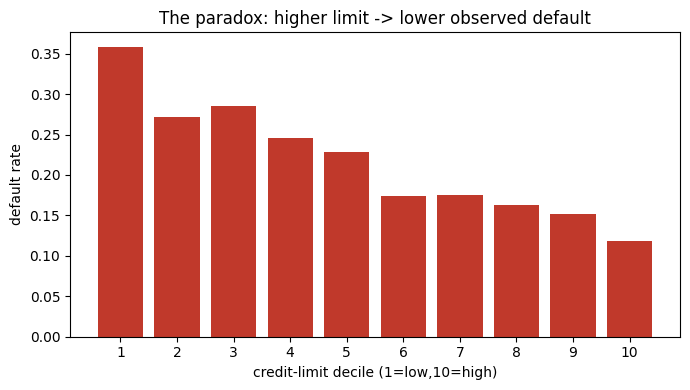

In [4]:
dec=uci.assign(dec=pd.qcut(uci['L'],10,labels=False,duplicates='drop')).groupby('dec').agg(
    n=('D','size'),limit=('L','mean'),default_rate=('D','mean'))
print('corr(limit, default) = %+.4f'%uci['L'].corr(uci['D']))
print(dec.round(4).to_string())
fig,ax=plt.subplots(figsize=(7,4)); ax.bar(range(len(dec)),dec['default_rate'],color='#c0392b')
ax.set_xticks(range(len(dec))); ax.set_xticklabels(range(1,len(dec)+1))
ax.set_xlabel('credit-limit decile (1=low,10=high)'); ax.set_ylabel('default rate')
ax.set_title('The paradox: higher limit -> lower observed default')
fig.tight_layout(); fig.savefig('figures/1_paradox.png',dpi=130); plt.show()

### 1-2. 디바이어싱 체인 + 반사실(counterfactual)

순차 잔차화: `M_L: L~X → rL`, `M_B: B~X`, `M_p: D~X(calibrated)`, 그리고 잔차 체인 `M_dB: rB~[X,rL]`, `M_dp: D~[X,rB] offset=logit(p̂)`.
교차적합(cross-fitting)으로 누수 차단, |rL| 가중. 매개변수를 **잔액/사용률/직접** 으로 바꿔 한도→부도 반사실 기울기를 비교한다.

counterfactual limit slope (0.5x->2.0x), negative = paradox direction:
  naive    -0.0389
  balance  -0.0043
  util     -0.0251
  direct   -0.0298
chain links: corr(rL,rB)=+0.140  corr(rL,rU)=-0.392  corr(rB,D-phat)=+0.021  corr(rU,D-phat)=+0.050


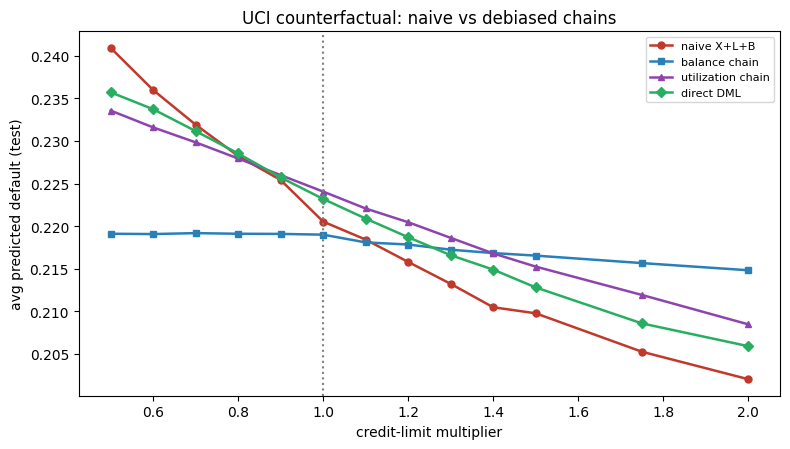

In [5]:
tr,te=train_test_split(uci,test_size=0.2,stratify=uci['D'],random_state=SEED)
tr=tr.reset_index(drop=True); te=te.reset_index(drop=True)
Xtr,Xte=tr[X_COLS],te[X_COLS]
Ltr,Lte=tr['L'].values,te['L'].values; Btr,Bte=tr['B'].values,te['B'].values
Utr,Ute=tr['U'].values,te['U'].values; Dtr,Dte=tr['D'].values,te['D'].values
skf=StratifiedKFold(5,shuffle=True,random_state=SEED); sp=list(skf.split(Xtr,Dtr))
def oof_reg(y):
    o=np.zeros(len(tr))
    for a,b in sp: o[b]=lgb.LGBMRegressor(**REG).fit(Xtr.iloc[a],y[a]).predict(Xtr.iloc[b])
    return o
oL,oB,oU=oof_reg(Ltr),oof_reg(Btr),oof_reg(Utr)
oP=np.zeros(len(tr))
for a,b in sp: oP[b]=lgb.LGBMClassifier(**CLF).fit(Xtr.iloc[a],Dtr[a]).predict_proba(Xtr.iloc[b])[:,1]
cal=IsotonicRegression(out_of_bounds='clip').fit(oP,Dtr); phat_tr=cal.transform(oP)
rL,rB,rU=Ltr-oL,Btr-oB,Utr-oU; off_tr=logit(phat_tr); w=0.1+np.abs(rL)/(rL.std()+1e-9)
Lh=lgb.LGBMRegressor(**REG).fit(Xtr,Ltr).predict(Xte); Bh=lgb.LGBMRegressor(**REG).fit(Xtr,Btr).predict(Xte)
Uh=lgb.LGBMRegressor(**REG).fit(Xtr,Utr).predict(Xte)
phat_te=cal.transform(lgb.LGBMClassifier(**CLF).fit(Xtr,Dtr).predict_proba(Xte)[:,1]); off_te=logit(phat_te)
rL_te=Lte-Lh
m_dB=lgb.LGBMRegressor(**REG).fit(Xtr.assign(rL=rL),rB,sample_weight=w)
m_dU=lgb.LGBMRegressor(**REG).fit(Xtr.assign(rL=rL),rU,sample_weight=w)
def fit_dp(fn,rf):
    return lgb.train(DP,lgb.Dataset(Xtr.assign(**{fn:rf}),label=Dtr,weight=w,init_score=off_tr),num_boost_round=200)
m_dpB,m_dpU,m_dpL=fit_dp('rB',rB),fit_dp('rU',rU),fit_dp('rL',rL)
m_naive=lgb.LGBMClassifier(**CLF).fit(Xtr.assign(L=Ltr,B=Btr),Dtr)
mults=np.array([0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.75,2])
cur={'naive':[],'balance':[],'util':[],'direct':[]}
for m in mults:
    cur['naive'].append(m_naive.predict_proba(Xte.assign(L=Lte*m,B=Bte))[:,1].mean())
    rLcf=Lte*m-Lh
    cur['balance'].append(sig(off_te+m_dpB.predict(Xte.assign(rB=m_dB.predict(Xte.assign(rL=rLcf))),raw_score=True)).mean())
    cur['util'].append(sig(off_te+m_dpU.predict(Xte.assign(rU=m_dU.predict(Xte.assign(rL=rLcf))),raw_score=True)).mean())
    cur['direct'].append(sig(off_te+m_dpL.predict(Xte.assign(rL=rLcf),raw_score=True)).mean())
print('counterfactual limit slope (0.5x->2.0x), negative = paradox direction:')
for k in cur: print('  %-8s %+.4f'%(k,cur[k][-1]-cur[k][0]))
print('chain links: corr(rL,rB)=%+.3f  corr(rL,rU)=%+.3f  corr(rB,D-phat)=%+.3f  corr(rU,D-phat)=%+.3f'%(
    wcorr(rL,rB),wcorr(rL,rU),wcorr(rB,Dtr-phat_tr),wcorr(rU,Dtr-phat_tr)))
fig,ax=plt.subplots(figsize=(8,4.6))
sty={'naive':('#c0392b','o','naive X+L+B'),'balance':('#2980b9','s','balance chain'),
     'util':('#8e44ad','^','utilization chain'),'direct':('#27ae60','D','direct DML')}
for k,(c,mk,lab) in sty.items(): ax.plot(mults,cur[k],marker=mk,color=c,lw=1.8,ms=5,label=lab)
ax.axvline(1,color='gray',ls=':'); ax.set_xlabel('credit-limit multiplier'); ax.set_ylabel('avg predicted default (test)')
ax.set_title('UCI counterfactual: naive vs debiased chains'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('figures/2_counterfactual.png',dpi=130); plt.show()

### 1-3. 약한 잔차 신호엔 선형 2차 스테이지 (GBM은 과적합)

`M_dp`를 GBM(X+rB) vs 잔차만 선형 GLM(rB)로 비교. GBM은 과적합(train-test AUC 격차 큼), 선형은 base와 동급 + 유의한 양(+)의 잔액→부도 효과를 복원.

In [6]:
def met(y,p): return roc_auc_score(y,p),brier_score_loss(y,p)
pfin_tr=sig(off_tr+m_dpB.predict(Xtr.assign(rB=rB),raw_score=True))
pfin_te=sig(off_te+m_dpB.predict(Xte.assign(rB=Bte-Bh),raw_score=True))
a_tr,_=met(Dtr,pfin_tr); a_te,_=met(Dte,pfin_te); ab_tr,_=met(Dtr,phat_tr); ab_te,_=met(Dte,phat_te)
print('GBM(X+rB)  train AUC %.4f  test AUC %.4f  -> overfit gap %+.4f'%(a_tr,a_te,a_tr-a_te))
print('base phat  train AUC %.4f  test AUC %.4f  -> gap %+.4f'%(ab_tr,ab_te,ab_tr-ab_te))
# linear DML: balance->default coef (offset = logit(phat)), |rL|-weighted
glm=sm.GLM(Dtr,sm.add_constant(pd.DataFrame({'rB':rB})),family=sm.families.Binomial(),
           offset=off_tr,freq_weights=w*len(w)/w.sum()).fit()
wls=sm.WLS(rB,sm.add_constant(pd.DataFrame({'rL':rL})),weights=w).fit()
print('linear: dB/dL = %+.4f (p=%.1e) ; balance->default theta = %+.3e (p=%.3f)'%(
    wls.params['rL'],wls.pvalues['rL'],glm.params['rB'],glm.pvalues['rB']))
print('=> balance channel of premise #1 holds (significant +), but tiny; total effect ~0/neg (utilization dominates).')

GBM(X+rB)  train AUC 0.8060  test AUC 0.7591  -> overfit gap +0.0469
base phat  train AUC 0.7719  test AUC 0.7636  -> gap +0.0083
linear: dB/dL = +0.0572 (p=2.8e-171) ; balance->default theta = +1.397e-06 (p=0.001)
=> balance channel of premise #1 holds (significant +), but tiny; total effect ~0/neg (utilization dominates).


### 1-4. 다른 편향: 관측창/연명(생존) 편향

디바이어싱은 교란을 제거하지만, 부도 정의가 짧으면(여기 1개월) "한도가 안전하게 한다 vs 부도를 미룬다(연명)"를 구분 못 한다.
행동군별 한도효과 + 관측창 1→5개월 연장 실험.

In [7]:
# behavioral-group debiased limit effect (full-data cross-fit)
Xf=uci[X_COLS]; Lf=uci['L'].values; Df=uci['D'].values
skf2=StratifiedKFold(5,shuffle=True,random_state=SEED)
oLf=np.zeros(len(uci)); oPf=np.zeros(len(uci))
for a,b in skf2.split(Xf,Df):
    oLf[b]=lgb.LGBMRegressor(**REG).fit(Xf.iloc[a],Lf[a]).predict(Xf.iloc[b])
    oPf[b]=lgb.LGBMClassifier(**CLF).fit(Xf.iloc[a],Df[a]).predict_proba(Xf.iloc[b])[:,1]
phf=IsotonicRegression(out_of_bounds='clip').fit(oPf,Df).transform(oPf)
rLf=Lf-oLf; rDf=Df-phf; wf=0.1+np.abs(rLf)/(rLf.std()+1e-9)
util=uci['B'].values/Lf; pr=np.where(uci['BILL_AMT2'].values>0,uci['PAY_AMT1'].values/np.maximum(uci['BILL_AMT2'].values,1),1.0)
grp={'transactor(pay>=80%)':pr>=0.8,'revolver-light':(pr<0.8)&(util<0.6),
     'revolver-heavy':(pr<0.3)&(util>=0.6),'delinquent(PAY_0>=1)':uci['PAY_0'].values>=1}
print('debiased limit effect corr(rL, D-phat) by behavior group (neg = "protective"):')
print('  %-26s n=%5d  %+.4f'%('ALL',len(uci),wcorr(rLf,rDf,wf)))
for k,mk in grp.items(): print('  %-26s n=%5d  %+.4f'%(k,mk.sum(),wcorr(rLf[mk],rDf[mk],wf[mk])))
print('=> "protection" concentrates in light revolvers, ~0 in delinquent/heavy => strong forbearance NOT supported (1-mo window cannot see later default).')

debiased limit effect corr(rL, D-phat) by behavior group (neg = "protective"):
  ALL                        n=30000  -0.0498
  transactor(pay>=80%)       n=10267  +0.0069
  revolver-light             n= 9068  -0.1051
  revolver-heavy             n=10553  +0.0093
  delinquent(PAY_0>=1)       n= 6818  -0.0064
=> "protection" concentrates in light revolvers, ~0 in delinquent/heavy => strong forbearance NOT supported (1-mo window cannot see later default).


debiased limit effect corr(rL, Y-phat) as default window lengthens:
  1m  base_rate 0.117  debiased corr -0.0642
  2m  base_rate 0.171  debiased corr -0.0934
  3m  base_rate 0.219  debiased corr -0.1192
  4m  base_rate 0.247  debiased corr -0.1325
  5m  base_rate 0.345  debiased corr -0.1349


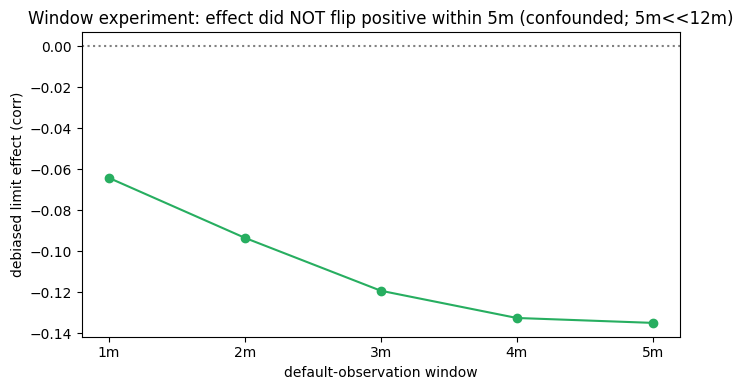

In [8]:
# horizon experiment: fix features at Apr/May, lengthen default window 1->5 months
H=['SEX','EDUCATION','MARRIAGE','AGE','PAY_5','PAY_6','BILL_AMT5','BILL_AMT6','PAY_AMT5','PAY_AMT6']
Xh=uci[H]; Lh2=uci['L'].values
oLh=np.zeros(len(uci))
for a,b in StratifiedKFold(5,shuffle=True,random_state=SEED).split(Xh,(Lh2>Lh2.mean()).astype(int)):
    oLh[b]=lgb.LGBMRegressor(**REG).fit(Xh.iloc[a],Lh2[a]).predict(Xh.iloc[b])
rLh=Lh2-oLh; wh=0.1+np.abs(rLh)/(rLh.std()+1e-9)
P4,P3,P2,P0=[uci[c].values for c in ['PAY_4','PAY_3','PAY_2','PAY_0']]; DEF=uci['D'].values
ev={'1m':(P4>=2),'2m':(P4>=2)|(P3>=2),'3m':(P4>=2)|(P3>=2)|(P2>=2),
    '4m':(P4>=2)|(P3>=2)|(P2>=2)|(P0>=2),'5m':(P4>=2)|(P3>=2)|(P2>=2)|(P0>=2)|(DEF==1)}
print('debiased limit effect corr(rL, Y-phat) as default window lengthens:')
debs=[]
for k,y in ev.items():
    y=y.astype(int); o=np.zeros(len(uci))
    for a,b in StratifiedKFold(5,shuffle=True,random_state=SEED).split(Xh,y): o[b]=lgb.LGBMClassifier(**CLF).fit(Xh.iloc[a],y[a]).predict_proba(Xh.iloc[b])[:,1]
    ph=IsotonicRegression(out_of_bounds='clip').fit(o,y).transform(o); d=wcorr(rLh,y-ph,wh); debs.append(d)
    print('  %-3s base_rate %.3f  debiased corr %+.4f'%(k,y.mean(),d))
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(range(1,6),debs,'o-',color='#27ae60'); ax.axhline(0,color='gray',ls=':')
ax.set_xticks(range(1,6)); ax.set_xticklabels(['1m','2m','3m','4m','5m'])
ax.set_xlabel('default-observation window'); ax.set_ylabel('debiased limit effect (corr)')
ax.set_title('Window experiment: effect did NOT flip positive within 5m (confounded; 5m<<12m)')
fig.tight_layout(); fig.savefig('figures/4_horizon.png',dpi=130); plt.show()

---
## 2. Lending Club — 장기 관측창 (charge-off), 인출 여신 vs 미사용 한도

만기 완료 대출(2007–2013). **인출된 여신(`loan_amnt`)** vs **미사용 리볼빙 한도(`total_rev_hi_lim`)** 의 디바이어싱 효과를 비교한다.

In [9]:
dfs=[pd.read_csv('data/lc/'+f,skiprows=1,low_memory=False) for f in ['LoanStats3a.csv','LoanStats3b.csv']]
lc=pd.concat(dfs,ignore_index=True)
lc=lc[lc['loan_amnt'].notna() & lc['loan_status'].notna()]
lc=lc[~lc['loan_status'].str.startswith('Does not meet')].copy()
lc['co']=lc['loan_status'].str.contains('Charged Off').astype(int)
pct=lambda s: pd.to_numeric(s.astype(str).str.rstrip('%'),errors='coerce')
lc['int_rate']=pct(lc['int_rate']); lc['revol_util']=pct(lc['revol_util'])
lc['term_n']=lc['term'].astype(str).str.extract(r'(\d+)').astype(float)
emp={'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10}
lc['emp_n']=lc['emp_length'].map(emp).fillna(-1); lc['grade_n']=lc['grade'].map({g:i for i,g in enumerate('ABCDEFG',1)})
lc['subg_n']=lc['sub_grade'].astype(str).apply(lambda s:(ord(s[0])-64)*5+int(s[1]) if len(s)==2 and s[0].isalpha() else np.nan)
for c in ['home_ownership','purpose','verification_status']: lc[c+'_n']=lc[c].astype('category').cat.codes
for c in ['annual_inc','dti','revol_bal','revol_util','total_rev_hi_lim','open_acc','delinq_2yrs','inq_last_6mths','loan_amnt']:
    lc[c]=pd.to_numeric(lc[c],errors='coerce')
lc=lc.dropna(subset=['int_rate','grade_n','subg_n','term_n','annual_inc','dti','loan_amnt','co'])
lc['annual_inc']=lc['annual_inc'].clip(upper=lc['annual_inc'].quantile(0.99))
print('Lending Club N=%d  charge-off rate=%.3f (matured 2007-2013)'%(len(lc),lc['co'].mean()))
LCX=['term_n','int_rate','grade_n','subg_n','annual_inc','dti','emp_n','home_ownership_n','purpose_n',
     'verification_status_n','open_acc','delinq_2yrs','inq_last_6mths','revol_bal','revol_util','total_rev_hi_lim']
for c in ['open_acc','delinq_2yrs','inq_last_6mths','revol_bal','revol_util','total_rev_hi_lim']: lc[c]=lc[c].fillna(lc[c].median())
Dlc=lc['co'].values

Lending Club N=227967  charge-off rate=0.155 (matured 2007-2013)


Lending Club debiased effects:
  loan_amnt          raw corr +0.0569 | debiased coef +0.000 (p=2.1e-137) | counterfactual slope naive +0.0410 / debiased +0.0564
  total_rev_hi_lim   raw corr -0.0285 | debiased coef -0.000 (p=8.0e-06) | counterfactual slope naive -0.0016 / debiased -0.0005


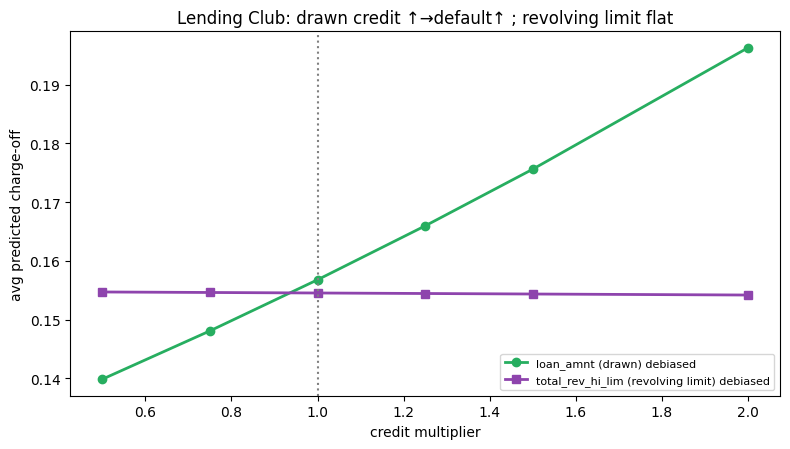

=> drawn loan_amnt: premise #1 holds (+); revolving limit ~0 (headroom).


In [10]:
def lc_effect(Tname):
    Xc=[c for c in LCX if c!=Tname]
    if Tname=='total_rev_hi_lim': Xc=[c for c in Xc if c!='revol_bal']
    X=lc[Xc]; T=lc[Tname].values.astype(float)
    sk=StratifiedKFold(5,shuffle=True,random_state=SEED); oT=np.zeros(len(lc)); oP=np.zeros(len(lc))
    for a,b in sk.split(X,Dlc):
        oT[b]=lgb.LGBMRegressor(**REG).fit(X.iloc[a],T[a]).predict(X.iloc[b])
        oP[b]=lgb.LGBMClassifier(**CLF).fit(X.iloc[a],Dlc[a]).predict_proba(X.iloc[b])[:,1]
    ph=IsotonicRegression(out_of_bounds='clip').fit(oP,Dlc).transform(oP); rT=T-oT; off=logit(ph)
    glm=sm.GLM(Dlc,sm.add_constant(pd.DataFrame({'rT':rT})),family=sm.families.Binomial(),
               offset=off,freq_weights=(0.1+np.abs(rT)/rT.std())*len(rT)/(0.1+np.abs(rT)/rT.std()).sum()).fit()
    mn=lgb.LGBMClassifier(**CLF).fit(lc[Xc].assign(**{Tname:T}),Dlc)
    mu=np.array([0.5,0.75,1,1.25,1.5,2]); nc=[];dc=[]
    for m in mu:
        nc.append(mn.predict_proba(lc[Xc].assign(**{Tname:T*m}))[:,1].mean())
        dc.append(sig(off+glm.params['const']+glm.params['rT']*(T*m-oT)).mean())
    print('  %-18s raw corr %+.4f | debiased coef %+.3f (p=%.1e) | counterfactual slope naive %+.4f / debiased %+.4f'%(
        Tname,np.corrcoef(T,Dlc)[0,1],glm.params['rT'],glm.pvalues['rT'],nc[-1]-nc[0],dc[-1]-dc[0]))
    return mu,np.array(nc),np.array(dc)
print('Lending Club debiased effects:')
m,n1,d1=lc_effect('loan_amnt'); m,n2,d2=lc_effect('total_rev_hi_lim')
fig,ax=plt.subplots(figsize=(8,4.6))
ax.plot(m,d1,'o-',color='#27ae60',lw=2,label='loan_amnt (drawn) debiased')
ax.plot(m,d2,'s-',color='#8e44ad',lw=2,label='total_rev_hi_lim (revolving limit) debiased')
ax.axvline(1,color='gray',ls=':'); ax.set_xlabel('credit multiplier'); ax.set_ylabel('avg predicted charge-off')
ax.set_title('Lending Club: drawn credit ↑→default↑ ; revolving limit flat'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('figures/5_lendingclub.png',dpi=130); plt.show()
print('=> drawn loan_amnt: premise #1 holds (+); revolving limit ~0 (headroom).')

---
## 3. Home Credit 신용카드 패널 — 대손 정의의 함정

동일 리볼빙 상품에서 실제 한도·잔액·연체를 추적. 그러나 카드 "부도(SK_DPD≥90)"는 대부분 **소액 잔액 방치 휴면계좌** → 사용률→부도가 UCI와 정반대(음)로 나오는 **정의 아티팩트**.

active HC cards=15821, 12m default=1.53%
HC default by utilization decile (%%): [13.96, 0.25, 0.25, 0.25, 0.06, 0.25, 0.06, 0.0, 0.06, 0.13]


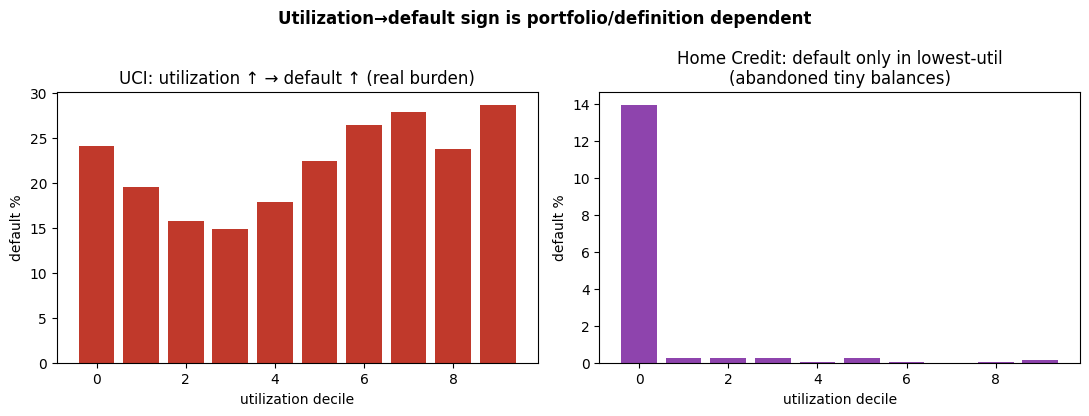

=> Among genuinely-active cards default collapses to ~0.1% -> underpowered; the "default" captures abandonment, not credit stress.


In [11]:
ccb=pd.read_csv('data/hc/credit_card_balance.csv',usecols=['SK_ID_PREV','MONTHS_BALANCE','AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL','SK_DPD'])
end=set(ccb.loc[ccb.MONTHS_BALANCE==-1,'SK_ID_PREV'])
base=ccb[ccb.MONTHS_BALANCE==-13].drop_duplicates('SK_ID_PREV').set_index('SK_ID_PREV')
cards=base.index[base.index.isin(end)]; base=base.loc[cards]
fwd=ccb[(ccb.MONTHS_BALANCE>=-12)&(ccb.MONTHS_BALANCE<=-1)&(ccb.SK_ID_PREV.isin(cards))]
d12=(fwd.groupby('SK_ID_PREV')['SK_DPD'].max().reindex(cards).fillna(0)>=90).astype(int)
h=pd.DataFrame({'limit':base['AMT_CREDIT_LIMIT_ACTUAL'].values,'bal':base['AMT_BALANCE'].values,'D':d12.values})
h=h[(h.limit>0)&(h.bal>0)].copy(); h['util']=h['bal']/h['limit']
h['uq']=pd.qcut(h['util'].clip(0,2),10,labels=False,duplicates='drop')
gh=h.groupby('uq').agg(util=('util','mean'),dr=('D','mean'))
gu=uci.assign(uq=pd.qcut((uci['B']/uci['L']).clip(-0.1,2),10,labels=False,duplicates='drop')).groupby('uq')['D'].mean()
print('active HC cards=%d, 12m default=%.2f%%'%(len(h),100*h['D'].mean()))
print('HC default by utilization decile (%%):',[round(100*x,2) for x in gh['dr'].values])
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.2))
a1.bar(range(len(gu)),100*gu.values,color='#c0392b'); a1.set_title('UCI: utilization ↑ → default ↑ (real burden)')
a1.set_xlabel('utilization decile'); a1.set_ylabel('default %')
a2.bar(range(len(gh)),100*gh['dr'].values,color='#8e44ad'); a2.set_title('Home Credit: default only in lowest-util\n(abandoned tiny balances)')
a2.set_xlabel('utilization decile'); a2.set_ylabel('default %')
fig.suptitle('Utilization→default sign is portfolio/definition dependent',fontweight='bold')
fig.tight_layout(); fig.savefig('figures/6_util_flip.png',dpi=130); plt.show()
print('=> Among genuinely-active cards default collapses to ~0.1% -> underpowered; the "default" captures abandonment, not credit stress.')

---
## 4. Home Credit 본 대출 — 역설이 뒤집히는 케이스 ✅

신청 대출(`TARGET` 부도 8%, 전액 인출 할부)에서 여신 변수를 EXT_SOURCE로 통제하면 **raw 음(−) 역설 → 디바이어싱 양(+)** 으로 flip.

Home Credit application loan N=307233  default(TARGET)=0.081
  AMT_CREDIT         raw corr -0.0304 (paradox) -> debiased coef +0.018 (p=6.0e-03)  FLIP
  AMT_ANNUITY        raw corr -0.0128 (paradox) -> debiased coef +0.059 (p=3.1e-20)  FLIP
  AMT_GOODS_PRICE    raw corr -0.0396 (paradox) -> debiased coef -0.010 (p=1.2e-01)  
  credit_to_income   raw corr -0.0081 (paradox) -> debiased coef +0.046 (p=1.5e-12)  FLIP


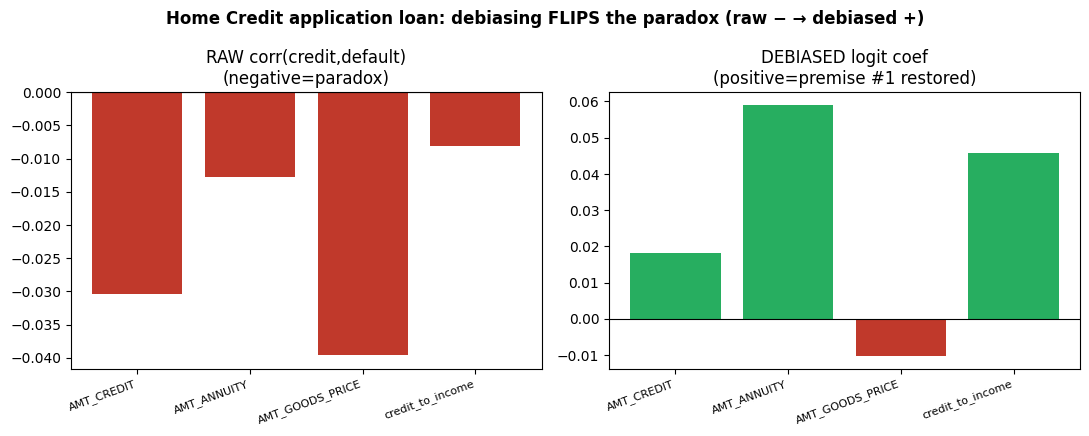

In [12]:
ap=pd.read_csv('data/hc/application_train.csv',usecols=['TARGET','AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL','AMT_GOODS_PRICE',
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','DAYS_BIRTH','DAYS_EMPLOYED','CODE_GENDER','CNT_FAM_MEMBERS','REGION_RATING_CLIENT'])
ap['DAYS_EMPLOYED']=ap['DAYS_EMPLOYED'].replace(365243,np.nan)
ap['age']=-ap['DAYS_BIRTH']/365; ap['emp']=(-ap['DAYS_EMPLOYED']/365).fillna((-ap['DAYS_EMPLOYED']/365).median())
ap['log_inc']=np.log1p(ap['AMT_INCOME_TOTAL'].clip(upper=ap['AMT_INCOME_TOTAL'].quantile(0.995)))
ap['gender']=(ap['CODE_GENDER']=='F').astype(int)
ap['credit_to_income']=(ap['AMT_CREDIT']/ap['AMT_INCOME_TOTAL'].clip(lower=1)).clip(upper=30)
for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']: ap[c+'_m']=ap[c].isna().astype(int); ap[c]=ap[c].fillna(ap[c].median())
ap['AMT_ANNUITY']=ap['AMT_ANNUITY'].fillna(ap['AMT_ANNUITY'].median()); ap['CNT_FAM_MEMBERS']=ap['CNT_FAM_MEMBERS'].fillna(ap['CNT_FAM_MEMBERS'].median())
ap=ap.dropna(subset=['AMT_CREDIT','AMT_GOODS_PRICE','TARGET'])
Da=ap['TARGET'].values
AX=['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','EXT_SOURCE_1_m','EXT_SOURCE_3_m','log_inc','age','emp','gender','CNT_FAM_MEMBERS','REGION_RATING_CLIENT']
print('Home Credit application loan N=%d  default(TARGET)=%.3f'%(len(ap),Da.mean()))
def zc(s):
    s=s.astype(float)
    if s.min()>=0 and s.max()>5: s=np.log1p(s)
    return (s-s.mean())/(s.std()+1e-9)
def flip(Tname):
    T=ap[Tname].values.astype(float); raw=np.corrcoef(T,Da)[0,1]
    X=ap[AX]; sk=StratifiedKFold(5,shuffle=True,random_state=SEED); oT=np.zeros(len(ap)); oP=np.zeros(len(ap))
    for a,b in sk.split(X,Da):
        oT[b]=lgb.LGBMRegressor(**REG).fit(X.iloc[a],T[a]).predict(X.iloc[b])
        oP[b]=lgb.LGBMClassifier(**CLF).fit(X.iloc[a],Da[a]).predict_proba(X.iloc[b])[:,1]
    ph=IsotonicRegression(out_of_bounds='clip').fit(oP,Da).transform(oP); rT=T-oT
    rTz=(rT-rT.mean())/rT.std(); fin=np.isfinite(rTz)
    glm=sm.Logit(Da[fin],sm.add_constant(pd.DataFrame({'rT':rTz[fin]}))).fit(disp=0)
    print('  %-18s raw corr %+.4f (paradox) -> debiased coef %+.3f (p=%.1e)  %s'%(
        Tname,raw,glm.params['rT'],glm.pvalues['rT'],'FLIP' if raw<-0.005 and glm.params['rT']>0 else ''))
    return raw,glm.params['rT']
res=[(t,)+flip(t) for t in ['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','credit_to_income']]
labels=[r[0] for r in res]; raws=[r[1] for r in res]; coefs=[r[2] for r in res]; x=np.arange(len(labels))
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.4))
a1.bar(x,raws,color=['#c0392b' if v<0 else '#27ae60' for v in raws]); a1.axhline(0,color='k',lw=.8)
a1.set_title('RAW corr(credit,default)\n(negative=paradox)'); a1.set_xticks(x); a1.set_xticklabels(labels,rotation=20,ha='right',fontsize=8)
a2.bar(x,coefs,color=['#27ae60' if v>0 else '#c0392b' for v in coefs]); a2.axhline(0,color='k',lw=.8)
a2.set_title('DEBIASED logit coef\n(positive=premise #1 restored)'); a2.set_xticks(x); a2.set_xticklabels(labels,rotation=20,ha='right',fontsize=8)
fig.suptitle('Home Credit application loan: debiasing FLIPS the paradox (raw − → debiased +)',fontweight='bold')
fig.tight_layout(); fig.savefig('figures/7_flip.png',dpi=130); plt.show()

---
## 5. raw(무통제) 한도-부도 직접 비교 — 역설은 '리볼빙 한도'의 보편적 특징

In [13]:
def deciletab(T,D,name):
    d=pd.DataFrame({'T':T,'D':D}).dropna(); d=d[d['T']>0]; d['q']=pd.qcut(d['T'],10,labels=False,duplicates='drop')
    g=d.groupby('q')['D'].mean(); pear=d['T'].corr(d['D'])
    print('  %-34s lo %.2f%% hi %.2f%%  raw corr %+.4f  %s'%(name,100*g.iloc[0],100*g.iloc[-1],pear,
        'PARADOX' if pear<-0.005 else ('no paradox(+)' if pear>0.005 else '~0')))
print('RAW limit/credit -> default:')
deciletab(uci['L'].values,uci['D'].values,'UCI limit (revolving)')
deciletab(lc['loan_amnt'].values,Dlc,'LC loan_amnt (drawn)')
deciletab(lc['total_rev_hi_lim'].values,Dlc,'LC total_rev_hi_lim (revolving)')
deciletab(h['limit'].values,h['D'].values,'HC card limit (active)')
deciletab(ap['AMT_CREDIT'].values,Da,'HC application AMT_CREDIT (drawn)')

RAW limit/credit -> default:
  UCI limit (revolving)              lo 35.85% hi 11.87%  raw corr -0.1535  PARADOX
  LC loan_amnt (drawn)               lo 13.75% hi 20.15%  raw corr +0.0569  no paradox(+)
  LC total_rev_hi_lim (revolving)    lo 17.22% hi 11.55%  raw corr -0.0286  PARADOX
  HC card limit (active)             lo 7.97% hi 0.07%  raw corr -0.1318  PARADOX
  HC application AMT_CREDIT (drawn)  lo 6.72% hi 5.33%  raw corr -0.0304  PARADOX


---
## 6. 종합 결론

| 신용의 종류 | raw 한도-부도 | 디바이어싱 후 | 사례 |
|---|---|---|---|
| 미사용 리볼빙 한도 | 음 (역설) | **≈0** | UCI · LC · HC 카드 |
| 인출 여신 + 약한 선택 | 양 (역설 없음) | 양 | LC 대출금 |
| **인출 여신 + 강한 선택** | **음 (역설)** | **양 (뒤집힘)** | **HC 본 대출** |

1. **방법(디바이어싱)은 타당하고 이식 가능** — 진짜 양(+)이 있을 때 깨끗이 복원하고, 조건이 맞으면 역설을 뒤집는다.
2. **"한도↑→부도↑"는 보편 법칙이 아니다** — 미사용 한도는 ≈0(headroom), 사용률·잔액 부호는 포트폴리오·대손 정의에 좌우.
3. **역설이 뒤집히는 전제조건**: ① 인출된 여신(실부담) + ② 강한 선택편향(raw 음). (그리고 대손 정의가 진짜 신용손실을 잡아야 함.)
4. **실무 데이터 진단 2가지**: ① 전이율 `dBalance/dLimit`, ② 대손 정의가 신용손실 vs 방치를 잡는지.

*본문 수치·그림은 모두 공개 데이터로 재현 가능. 실무 데이터의 부호는 위 ①②로 직접 검증할 것.*